# Evolución de una Acción con Qlib
Este notebook recupera los datos de una acción usando Qlib y muestra una gráfica de la evolución de su valor de cierre desde el 1 de enero de 2020.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import qlib
from qlib.data import D
from qlib.config import REG_US
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Configurar el ticker y la fecha de inicio
TICKER = "^GSPC"  # Cambia esto por el ticker que desees analizar (ej: TSLA, MSFT, NVO, GLD)
START_DATE = "2020-01-01"

# Inicializar Qlib con los datos de mercado de US
# Nota: provider_uri debe apuntar a donde tengas descargados los datos de Qlib.
provider_uri = '~/.qlib/qlib_data/us_data'
try:
    qlib.init(provider_uri=provider_uri, region=REG_US)
    print("Qlib inicializado correctamente.")
except Exception as e:
    print(f"Aviso al inicializar Qlib: {e}")

[459521:MainThread](2026-03-19 16:03:15,373) INFO - qlib.Initialization - [config.py:453] - default_conf: client.
[459521:MainThread](2026-03-19 16:03:17,111) INFO - qlib.Initialization - [__init__.py:82] - qlib successfully initialized based on client settings.
[459521:MainThread](2026-03-19 16:03:17,113) INFO - qlib.Initialization - [__init__.py:84] - data_path={'__DEFAULT_FREQ': PosixPath('/home/toni/.qlib/qlib_data/us_data')}


Qlib inicializado correctamente.


Recuperando datos para ^GSPC desde 2020-01-01...


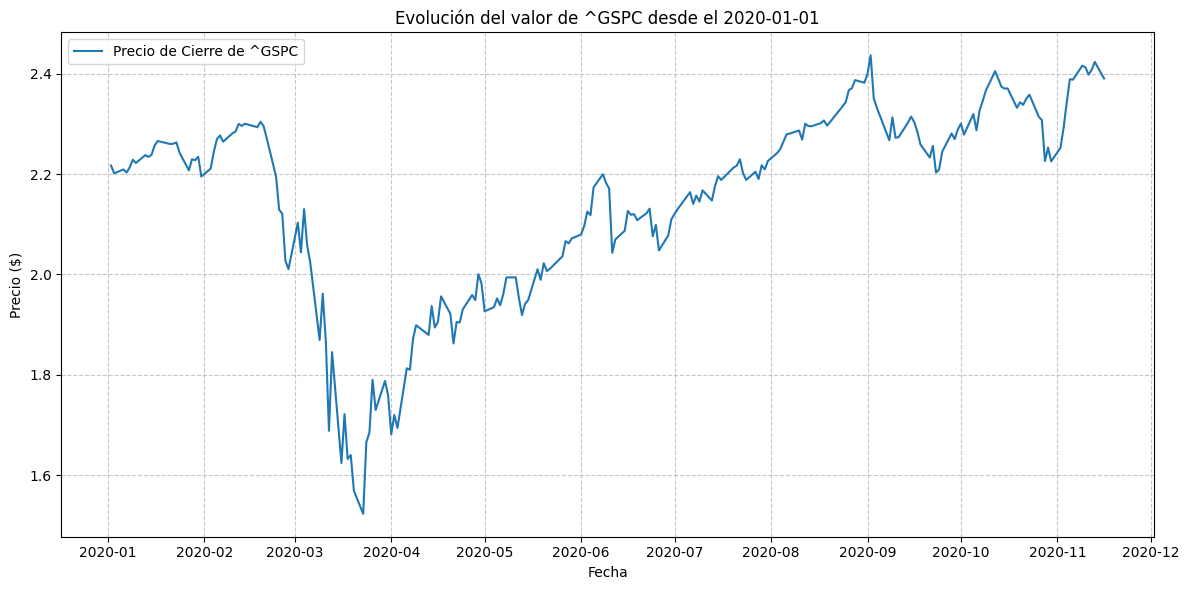

In [3]:
print(f"Recuperando datos para {TICKER} desde {START_DATE}...")

# Recuperar el precio de cierre ($close) de la acción
instruments = [TICKER]
fields = ['$close']
try:
    df = D.features(instruments, fields, start_time=START_DATE)
except Exception as e:
    print(f"Error al recuperar datos: {e}")
    df = None

if df is not None and not df.empty:
    # Qlib devuelve un DataFrame con MultiIndex (instrument, datetime).
    # Seleccionamos solo los datos del ticker especificado
    df_ticker = df.loc[TICKER]
    
    # Crear la gráfica
    plt.figure(figsize=(12, 6))
    plt.plot(df_ticker.index, df_ticker['$close'], label=f'Precio de Cierre de {TICKER}', color='#1f77b4')
    
    plt.title(f'Evolución del valor de {TICKER} desde el {START_DATE}')
    plt.xlabel('Fecha')
    plt.ylabel('Precio ($)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    
    plt.show()
else:
    print(f"No se encontraron datos para el ticker {TICKER} desde {START_DATE}.")

In [4]:
# Configurar pandas para mostrar todas las columnas sin ocultarlas
pd.set_option('display.max_columns', None)

# Especificar las columnas (features) que queremos traer de Qlib
instruments = [TICKER]
fields = ['$open', '$high', '$low', '$close', '$volume', '$amount', '$factor']

print(f"Recuperando todas las columnas para {TICKER}...")
df_all = D.features(instruments, fields, start_time=START_DATE)

if df_all is not None and not df_all.empty:
    # Qlib devuelve un MultiIndex, seleccionamos el ticker en cuestión
    df_ticker_all = df_all.loc[TICKER]
    
    # Extraer exactamente los últimos 40 registros
    df_40 = df_ticker_all.tail(40)
    
    print(f"Últimos 40 registros de {TICKER} con las columnas extraídas:")
    display(df_40)
else:
    print(f"No se encontraron datos para {TICKER}.")

Recuperando todas las columnas para ^GSPC...
Últimos 40 registros de ^GSPC con las columnas extraídas:


,$open,$high,$low,$close,$volume,$amount,$factor
datetime,,,,,,,
2020-09-22,2.243151,2.259867,2.226272,2.256641,5.823079e+12,NaN,0.000681
2020-09-23,2.259731,2.261936,2.200150,2.203110,6.412542e+12,NaN,0.000681
2020-09-24,2.195773,2.231547,2.184414,2.209692,6.757771e+12,NaN,0.000681
2020-09-25,2.202933,2.250726,2.197339,2.244996,5.571719e+12,NaN,0.000681
2020-09-28,2.269117,2.287385,2.268443,2.281164,5.797749e+12,NaN,0.000681
2020-09-29,2.280701,2.285465,2.264788,2.270185,5.365525e+12,NaN,0.000681
2020-09-30,2.274092,2.309723,2.273589,2.288923,6.938577e+12,NaN,0.000681
2020-10-01,2.304489,2.312186,2.287827,2.301038,5.980626e+12,NaN,0.000681
2020-10-02,2.272547,2.293075,2.262168,2.278999,5.820507e+12,NaN,0.000681


In [6]:
# Extraer el precio de cierre y el factor de ajuste
df = D.features(['NVO'], ['$close', '$factor'], start_time='2020-03-01', end_time='2026-12-31')
print(df)

                           $close   $factor
instrument datetime                        
NVO        2020-03-02  168.582718  2.758225
           2020-03-03  169.630844  2.758225
           2020-03-04  178.677826  2.758225
           2020-03-05  173.630280  2.758225
           2020-03-06  172.526978  2.758225
...                           ...       ...
           2020-11-04  197.218506  2.818615
           2020-11-05  201.700089  2.818615
           2020-11-06  198.317764  2.818615
           2020-11-09  191.496719  2.818615
           2020-11-10  190.341080  2.818615

[178 rows x 2 columns]


In [9]:
# Extraer el precio de cierre y el factor de ajuste
df = D.features(['JPM'], ['$close', '$factor'], start_time='2020-03-01', end_time='2026-12-31')
print(df)

                         $close   $factor
instrument datetime                      
JPM        2020-03-02  4.249108  0.034966
           2020-03-03  4.089662  0.034966
           2020-03-04  4.190714  0.034966
           2020-03-05  3.985112  0.034966
           2020-03-06  3.779160  0.034966
...                         ...       ...
           2020-11-10  4.195300  0.036005
           2020-11-11  4.203456  0.036005
           2020-11-12  4.252045  0.036005
           2020-11-13  4.312168  0.036005
           2020-11-16  4.324944  0.036005

[182 rows x 2 columns]


In [8]:
# Extraer el precio de cierre y el factor de ajuste
df = D.features(['^NDX'], ['$close', '$factor'], start_time='2026-03-01', end_time='2026-12-31')
print(df)

                         $close  $factor
instrument datetime                     
^NDX       2026-03-02  6.740492  0.00027
           2026-03-03  6.666994  0.00027
           2026-03-04  6.767754  0.00027
           2026-03-05  6.747993  0.00027
           2026-03-06  6.646211  0.00027
           2026-03-09  6.733655  0.00027
           2026-03-10  6.730748  0.00027
           2026-03-11  6.733051  0.00027
           2026-03-12  6.616695  0.00027
           2026-03-13  6.575471  0.00027
           2026-03-16  6.649533  0.00027
           2026-03-17  6.683268  0.00027
           2026-03-18  6.587435  0.00027
